In [ ]:
# Import required libraries for data processing, visualization, and machine learning
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Upload dataset in Google Colab
from google.colab import files
uploaded = files.upload()

Saving ai_jobs_market_2025_2026.csv to ai_jobs_market_2025_2026.csv


In [ ]:
# Load the dataset
df = pd.read_csv("ai_jobs_market_2025_2026.csv")


In [ ]:
# Check number of duplicate rows
df.duplicated().sum()

np.int64(0)

In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
job_id,0
job_title,0
job_category,0
experience_level,0
years_of_experience,0
education_required,0
annual_salary_usd,0
salary_min_usd,0
salary_max_usd,0
city,0


In [ ]:
# Display data types of all columns
df.dtypes

,0
job_id,object
job_title,object
job_category,object
experience_level,object
years_of_experience,int64
education_required,object
annual_salary_usd,float64
salary_min_usd,int64
salary_max_usd,int64
city,object


In [ ]:
# Convert selected columns to object type (categorical)
df["job_title"]=df["job_title"].astype("object")
df["education_required"]=df["education_required"].astype("object")

Correlation Matrix:
                       years_of_experience  annual_salary_usd  salary_min_usd  \
years_of_experience               1.000000           0.078643        0.251169   
annual_salary_usd                 0.078643           1.000000        0.421042   
salary_min_usd                    0.251169           0.421042        1.000000   
salary_max_usd                    0.173499           0.426631        0.742550   
ai_salary_premium_pct             0.138649          -0.019829       -0.076302   
demand_score                     -0.096144           0.291800        0.524296   
demand_growth_yoy_pct            -0.121351           0.142776        0.182718   
benefits_score_10                -0.036842          -0.014715       -0.008016   
posting_year                     -0.002132           0.022232        0.045599   
posting_month                     0.038534          -0.024256       -0.046918   
is_senior                         0.007020           0.486629        0.018862   
is_remot

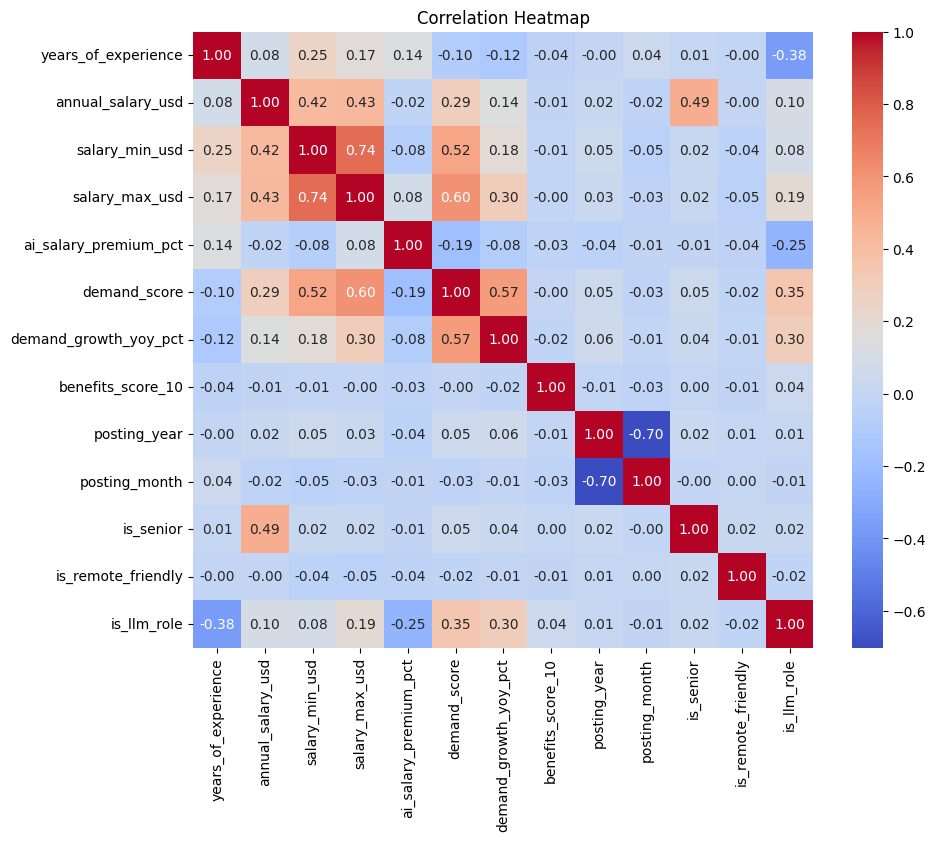

In [ ]:
#Select numerical columns
num_df = df.select_dtypes(include=['int64', 'float64'])

# Calculate correlation matrix
corr_matrix = num_df.corr()

# Print correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:

# Create groups
    groups = [group['annual_salary_usd'].values for name, group in df.groupby(col)]

    if len(groups) > 1:
        f_stat, p_value = f_oneway(*groups)

        print(f"\nColumn: {col}")
        print("F-Statistic:", f_stat)
        print("P-Value:", p_value)
  # Check statistical significance
        if p_value < 0.05:
            print("Significant relationship with annual_salary_usd")
        else:
            print("No significant relationship with annual_salary_usd")


Column: job_id
F-Statistic: nan
P-Value: nan
No significant relationship with annual_salary_usd

Column: job_title
F-Statistic: 17.036369599670625
P-Value: 2.1989758017781813e-62
Significant relationship with annual_salary_usd

Column: job_category
F-Statistic: 19.415777424283064
P-Value: 6.8658383255365e-37
Significant relationship with annual_salary_usd

Column: experience_level
F-Statistic: 188.78401453287867
P-Value: 8.226321008237093e-104
Significant relationship with annual_salary_usd

Column: education_required
F-Statistic: 14.815071146925286
P-Value: 7.081359906263139e-12
Significant relationship with annual_salary_usd

Column: city
F-Statistic: 19.928287977327166
P-Value: 1.869012924221211e-60
Significant relationship with annual_salary_usd

Column: country
F-Statistic: 26.669852219647556
P-Value: 5.128432662003208e-59
Significant relationship with annual_salary_usd

Column: remote_work
F-Statistic: 0.8559538214417839
P-Value: 0.42508557497543153
No significant relationship w

/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:573: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_537/67606343.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:573: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
/tmp/ipykernel_537/67606343.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = f_oneway(*groups)


In [ ]:
# Select important numerical and categorical features
num_df=['is_senior','salary_max_usd','salary_min_usd','years_of_experience']
cat_cols=['job_title','job_category','experience_level','education_required','city','country','company_size','salary_tier']


In [ ]:
# Create feature matrix (X) and target variable (y)
X = df[num_df + cat_cols].copy()
y = df["annual_salary_usd"]

In [ ]:
# Standardize numerical features
scaler = StandardScaler()
# Convert categorical variables into numerical format using One-Hot Encoding
X[num_df] = scaler.fit_transform(X[num_df])
X = pd.get_dummies(X, columns=cat_cols)


In [ ]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print evaluation results
print("Mean Squared Error:", mse)
print("R2 Score:", r2)
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))


Mean Squared Error: 255158261.4457308
R2 Score: 0.9377507876561466
Mean Absolute Error: 12158.448673552091


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))


Random Forest MSE: 252478009.55997163
Random Forest R2: 0.938404670339883
Mean Absolute Error: 12158.448673552091


In [ ]:
# Create model
gb = GradientBoostingRegressor(random_state=42)

# Train model
gb.fit(X_train, y_train)

# Predict
y_pred_gb = gb.predict(X_test)

# Evaluation
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

print("\nGradient Boosting Results")
print("MSE:", mse_gb)
print("R2 Score:", r2_gb)
print("MAE:", mae_gb)


Gradient Boosting Results
MSE: 237471241.1178359
R2 Score: 0.9420657687893573
MAE: 11426.537114740579
